In [178]:
import numpy as np
import os
from pathlib import Path
import pandas as pd

from astropy.io import fits

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import Ellipse
from matplotlib.ticker import FuncFormatter, LinearLocator
matplotlib.rcParams['figure.dpi'] = 360
matplotlib.rcParams['text.usetex'] = True
os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ['PATH']
plt.style.use('dark_background')
cmap = sns.color_palette('mako', as_cmap=True)

### Fisher matrix

$$F_{\alpha\beta} = \frac{\partial \mathbf{O}^{T}}{\partial \theta_{\alpha}} \, \mathbf{C}^{-1} \, \frac{\partial \mathbf{O}}{\partial \theta_{\beta}}$$


If there's changes in the hod parameters:
$$\theta = \{\omega_b,\omega_{\mathrm{cdm}},n_s,\sigma_8, \theta_{\mathrm{HOD},1}, \theta_{\mathrm{HOD},2}, ..., \theta_{\mathrm{HOD},i}, \}$$

Now $F$ would be:

$$\theta_{\mathrm{cosmo}} = \{\omega_b, \omega_{\mathrm{cdm}}, n_s, \sigma_8\}$$

$$\theta_{\mathrm{full}} = \{\theta_{\mathrm{cosmo}}, \theta_{\mathrm{HOD}}\}$$

$$F = \begin{pmatrix}
F_{\mathrm{cosmo},\mathrm{cosmo}} &
F_{\mathrm{cosmo},\mathrm{HOD}} \\
F_{\mathrm{HOD},\mathrm{cosmo}} &
F_{\mathrm{HOD},\mathrm{HOD}}
\end{pmatrix}$$

In [102]:
base = '/pscratch/sd/n/ntbfin/emulator/hods/z0.5/yuan23_prior'
!ls $base/c000_ph000/seed0/hod000.fits

/pscratch/sd/n/ntbfin/emulator/hods/z0.5/yuan23_prior/c000_ph000/seed0/hod000.fits


In [103]:
!ls /pscratch/sd/n/ntbfin/emulator/hods/z0.5/yuan23_prior/

c000_ph000  c109_ph000	c124_ph000  c142_ph000	c157_ph000  c172_ph000
c001_ph000  c110_ph000	c125_ph000  c143_ph000	c158_ph000  c173_ph000
c002_ph000  c111_ph000	c126_ph000  c144_ph000	c159_ph000  c174_ph000
c003_ph000  c112_ph000	c130_ph000  c145_ph000	c160_ph000  c175_ph000
c004_ph000  c113_ph000	c131_ph000  c146_ph000	c161_ph000  c176_ph000
c013_ph000  c114_ph000	c132_ph000  c147_ph000	c162_ph000  c177_ph000
c100_ph000  c115_ph000	c133_ph000  c148_ph000	c163_ph000  c178_ph000
c101_ph000  c116_ph000	c134_ph000  c149_ph000	c164_ph000  c179_ph000
c102_ph000  c117_ph000	c135_ph000  c150_ph000	c165_ph000  c180_ph000
c103_ph000  c118_ph000	c136_ph000  c151_ph000	c166_ph000  c181_ph000
c104_ph000  c119_ph000	c137_ph000  c152_ph000	c167_ph000
c105_ph000  c120_ph000	c138_ph000  c153_ph000	c168_ph000
c106_ph000  c121_ph000	c139_ph000  c154_ph000	c169_ph000
c107_ph000  c122_ph000	c140_ph000  c155_ph000	c170_ph000
c108_ph000  c123_ph000	c141_ph000  c156_ph000	c171_ph000


In [104]:
! find $base/c000_ph000/seed0 -maxdepth 1 -type f | wc -l

500


``hod091`` is in all of *my* cosmologies -> might use it as a 'base' value

For HOD:

$$\langle N_{\mathrm{gal}} (M) \rangle = \langle N_{\mathrm{cen}} (M) \rangle + \langle N_{\mathrm{sat}} (M) \rangle$$

$\langle N_{\mathrm{cen}} (M) \rangle$ -> mean number of cen gal in a halo of mass $M$

$\langle N_{\mathrm{sat}} (M) \rangle$ -> mean number of sat gal in that halo

In [105]:
def save_hod_params(folder, output_csv, ext=1):
    folder = Path(folder)
    rows = []
    params = ['GAL_TYPE', 'Q_PAR', 'Q_PERP',
              'LOGM_CUT', 'LOGM1', 'SIGMA', 'ALPHA', 'KAPPA',
              'ALPHA_C', 'ALPHA_S',
              'S', 'S_V', 'S_P', 'S_R',
              'ACENT', 'ASAT', 'BCENT', 'BSAT', 'IC']

    for path in sorted(folder.glob('hod*.fits')):
        with fits.open(path) as hdul:
            header = hdul[ext].header
            
        row = {'filename': path.name, 'hod': path.stem}
        for p in params:
            row[p] = header.get(p, None)
        rows.append(row)

    df = pd.DataFrame(rows)
    df.to_csv(output_csv, index=False)
    return df

In [106]:
# df_hods = save_hod_params(f'{base}/c000_ph000/seed0', './data/params_hods_c000_ph000_seed0.csv')
df_hods = pd.read_csv('./data/params_hods_c000_ph000_seed0.csv')
df_hods.columns

Index(['filename', 'hod', 'GAL_TYPE', 'Q_PAR', 'Q_PERP', 'LOGM_CUT', 'LOGM1',
       'SIGMA', 'ALPHA', 'KAPPA', 'ALPHA_C', 'ALPHA_S', 'S', 'S_V', 'S_P',
       'S_R', 'ACENT', 'ASAT', 'BCENT', 'BSAT', 'IC'],
      dtype='object')

``LOGM_CUT`` -> $\log_{10}{M_{\mathrm{cut}}}$ -> characteristic halo mass threshold for hosting a central galaxy

``LOGM1`` -> $\log_{10}{M_1}$ -> characteristic halo mass scale for hosting satellite galaxies

``SIGMA`` -> central occupation -> how soft/smooth the transition is between halos with and without a central galaxy

``ALPHA`` -> $\langle N_{\mathrm{sat}} (M) \rangle \propto \left( \frac{M - \kappa M_{\mathrm{cut}}}{M_1} \right) ^\alpha$ -> satellite occupation -> the slope of the satellite occupation, i.e. how quickly the number of satellites increases with halo mass

``KAPPA`` -> satellite occupation threshold -> sets the effective halo-mass threshold for satellite galaxies

In [107]:
cols = ['LOGM_CUT', 'LOGM1', 'SIGMA', 'ALPHA', 'KAPPA']

In [108]:
sub_df = df_hods[cols]

In [109]:
base = df_hods.loc[df_hods['hod']=='hod001', cols].iloc[0]
base

LOGM_CUT    13.490700
LOGM1       14.177533
SIGMA        5.710524
ALPHA        1.418342
KAPPA        0.903775
Name: 1, dtype: float64

In [110]:
delta = np.abs(sub_df-base)
delta

,LOGM_CUT,LOGM1,SIGMA,ALPHA,KAPPA
0,0.149290,0.305556,0.941714,0.007877,0.069256
1,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.132630,0.177905,0.584761,0.457291,0.748172
3,0.034320,0.227780,4.671718,0.986336,0.358184
4,0.855243,0.109104,5.707988,0.818508,0.677920
...,...,...,...,...,...
495,0.230398,0.827327,1.243935,0.048964,0.724356
496,0.773122,0.174538,5.600643,0.960258,0.565612
497,0.200988,0.016647,4.416289,0.968716,0.410298
498,0.701603,0.222529,5.548592,0.031060,0.861879


In [111]:
delta_hod = pd.concat([df_hods[['hod']], delta], axis=1)
delta_hod

,hod,LOGM_CUT,LOGM1,SIGMA,ALPHA,KAPPA
0,hod000,0.149290,0.305556,0.941714,0.007877,0.069256
1,hod001,0.000000,0.000000,0.000000,0.000000,0.000000
2,hod003,0.132630,0.177905,0.584761,0.457291,0.748172
3,hod004,0.034320,0.227780,4.671718,0.986336,0.358184
4,hod006,0.855243,0.109104,5.707988,0.818508,0.677920
...,...,...,...,...,...,...
495,hod863,0.230398,0.827327,1.243935,0.048964,0.724356
496,hod864,0.773122,0.174538,5.600643,0.960258,0.565612
497,hod865,0.200988,0.016647,4.416289,0.968716,0.410298
498,hod866,0.701603,0.222529,5.548592,0.031060,0.861879


### Read observables (P(k))

In [112]:
base_path = Path('/pscratch/sd/v/vtorresg/marked_pk')
cosmo_ids = ['100', '101', '102', '103', '104', '105', '112', '113']

In [113]:
def get_available_hods(cid):
    cosmo_dir = base_path / f'c{cid}'
    hods = []
    for p in cosmo_dir.glob('hod*'):
        if p.is_dir():
            hod_id = p.name.replace('hod', '')
            hods.append(hod_id)
    return sorted(hods)

def get_common_hods(cid_plus, cid_minus):
    hods_plus = set(get_available_hods(cid_plus))
    hods_minus = set(get_available_hods(cid_minus))
    common = sorted(hods_plus & hods_minus)
    return common

#### $\theta_{\mathrm{cosmo}}$

In [114]:
hods_wb = get_common_hods('100', '101')
hods_wcdm = get_common_hods('102', '103')
hods_ns = get_common_hods('104', '105')
hods_s8 = get_common_hods('112', '113')

In [115]:
pair_hods = {('100', '101'): hods_wb,
             ('102', '103'): hods_wcdm,
             ('104', '105'): hods_ns,
             ('112', '113'): hods_s8}

In [116]:
for pair, hods in pair_hods.items():
    print(pair, len(hods))

('100', '101') 290
('102', '103') 275
('104', '105') 274
('112', '113') 305


In [117]:
def load_pk_dataframe(cid, hod):
    filename = (base_path / f'c{cid}' / f'hod{hod}' /
                f'pk_pypower_HOD_c{cid}_ph000_seed0_hod{hod}_N256.csv')
    return pd.read_csv(filename)

In [118]:
def build_common_mask_for_pair(cid_plus, cid_minus, hod, kmin=kmin, kmax=kmax):
    df_plus = load_pk_dataframe(cid_plus, hod)
    df_minus = load_pk_dataframe(cid_minus, hod)
    
    mask = np.isfinite(df_plus[obs_cols]).all(axis=1)
    mask &= np.isfinite(df_minus[obs_cols]).all(axis=1)
    mask &= df_plus['k_h_mpc'].between(kmin, kmax).to_numpy()
    mask &= df_minus['k_h_mpc'].between(kmin, kmax).to_numpy()
    
    return mask

In [119]:
def build_observable_from_df(df, mask):
    return df.loc[mask, obs_cols].to_numpy().T.ravel()

In [120]:
def build_derivatives_for_pair(cid_plus, cid_minus, delta_param, hods_common,
                               kmin=0.02, kmax=0.20):
    D_list = []
    used_hods = []
    k_ref = None

    for hod in hods_common:
        df_plus = load_pk_dataframe(cid_plus, hod)
        df_minus = load_pk_dataframe(cid_minus, hod)

        mask = build_common_mask_for_pair(cid_plus, cid_minus, hod,
                                          kmin=kmin, kmax=kmax)
        if mask.sum() == 0:
            continue

        O_plus = build_observable_from_df(df_plus, mask)
        O_minus = build_observable_from_df(df_minus, mask)

        dO = (O_plus - O_minus) / delta_param

        D_list.append(dO)
        used_hods.append(hod)

    D_all = np.array(D_list)
    D_mean = D_all.mean(axis=0)
    D_std = D_all.std(axis=0, ddof=1)

    return D_mean, D_std, D_all, used_hods, k_ref

In [121]:
delta_wb = 0.02282 - 0.02193
delta_wcdm = 0.12400 - 0.11610
delta_ns = 0.97490 - 0.95490
delta_sigma8 = 0.824120 - 0.792107

In [122]:
dO_dwb_mean, dO_dwb_std, dO_dwb_all, used_hods_wb, k_wb = build_derivatives_for_pair('100', '101', delta_wb, hods_wb, kmin=kmin, kmax=kmax)
dO_dwb_mean.shape

(56,)

In [123]:
dO_dwcdm_mean, dO_dwcdm_std, dO_dwcdm_all, used_hods_wcdm, k_wcdm = build_derivatives_for_pair('102', '103', delta_wcdm, hods_wcdm, kmin=kmin, kmax=kmax)
dO_dwcdm_mean.shape

(56,)

In [124]:
dO_dns_mean, dO_dns_std, dO_dns_all, used_hods_ns, k_ns = build_derivatives_for_pair('104', '105', delta_ns, hods_ns, kmin=kmin, kmax=kmax)
dO_dns_mean.shape

(56,)

In [125]:
dO_dsigma8_mean, dO_dsigma8_std, dO_dsigma8_all, used_hods_s8, k_s8 = build_derivatives_for_pair('112', '113', delta_sigma8, hods_s8, kmin=kmin, kmax=kmax)
dO_dsigma8_mean.shape

(56,)

In [126]:
D_cosmo = np.vstack([dO_dwb_mean, dO_dwcdm_mean, dO_dns_mean, dO_dsigma8_mean])
D_cosmo.shape

(4, 56)

#### $\theta_{\mathrm{HOD}}$

In [127]:
def load_observable(cid, hod, kmin=0.02, kmax=0.20):
    df = load_pk_dataframe(cid, hod)

    mask = np.isfinite(df[obs_cols]).all(axis=1)
    mask &= df['k_h_mpc'].between(kmin, kmax).to_numpy()

    O = df.loc[mask, obs_cols].to_numpy().T.ravel()
    k = df.loc[mask, 'k_h_mpc'].to_numpy()

    return O, k

In [139]:
cid_fid = '000'
hod_fid = '091'

In [142]:
df_hods['hod_id'] = (df_hods['hod'].astype(str).str.replace('hod', '', regex=False).str.zfill(3))
hod_fid = str(hod_fid).replace('hod', '').zfill(3)

In [145]:
theta_fid_hod = df_hods.loc[df_hods['hod_id'] == hod_fid, cols].iloc[0].to_numpy(dtype=float)

In [146]:
O_fid_hod, k_ref = load_observable(cid_fid, hod_fid, kmin=kmin, kmax=kmax)

In [147]:
hods_fid = get_available_hods(cid_fid)

In [149]:
X_list = []
Y_list = []
used_hods_hod_deriv = []

for hod in hods_fid:

    if hod == hod_fid:
        continue

    row = df_hods.loc[df_hods['hod_id'] == hod]
    if len(row) == 0:
        continue

    theta_hod = row[cols].iloc[0].to_numpy(dtype=float)

    O_hod, k_this = load_observable(cid_fid, hod, kmin=kmin, kmax=kmax)

    if not np.allclose(k_this, k_ref):
        continue

    dtheta = theta_hod - theta_fid_hod
    dO = O_hod - O_fid_hod

    X_list.append(dtheta)
    Y_list.append(dO)
    used_hods_hod_deriv.append(hod)

In [150]:
X = np.array(X_list)
Y = np.array(Y_list)
X.shape, Y.shape

((499, 5), (499, 56))

``D_hod[0] = dO/dLOGM_CUT``

``D_hod[1] = dO/dLOGM1``

``D_hod[2] = dO/dSIGMA``

``D_hod[3] = dO/dALPHA``

``D_hod[4] = dO/dKAPPA``

In [151]:
D_hod, residuals, rank, svals = np.linalg.lstsq(X, Y, rcond=None)
D_hod.shape, rank, svals

((5, 56),
 np.int32(5),
 array([58.8391722 , 23.44001792,  8.46566217,  7.09492881,  6.59933794]))

#### $\theta_{\mathrm{full}}$

In [152]:
D_full = np.vstack([D_cosmo, D_hod])
D_full.shape

(9, 56)

In [153]:
param_names_full = ['omega_b', 'omega_cdm', 'n_s', 'sigma8',
                    'LOGM_CUT', 'LOGM1', 'SIGMA', 'ALPHA', 'KAPPA']

### Fisher!!

Getting Cov with the hods over the fiducial cosmo (just to see how it looks like before doing subsampling)

In [166]:
def build_fiducial_observable_matrix(hods_fid, kmin=kmin, kmax=kmax):
    O_fid_all = []
    k_ref = None
    
    for hod in hods_fid:
        df = load_pk_dataframe('000', hod)
        
        mask = np.isfinite(df[obs_cols]).all(axis=1)
        mask &= df['k_h_mpc'].between(kmin, kmax)
        
        k_this = df.loc[mask, 'k_h_mpc'].to_numpy()
        
        k_ref = k_this
        O = df.loc[mask, obs_cols].to_numpy().T.ravel()
        O_fid_all.append(O)
    
    O_fid_all = np.array(O_fid_all)
    
    return O_fid_all, k_ref

In [167]:
O_fid_all, k_cov = build_fiducial_observable_matrix(hods_fid, kmin=kmin, kmax=kmax)
O_fid_all.shape

(500, 56)

In [168]:
C = np.cov(O_fid_all, rowvar=False, ddof=1)
Cinv = np.linalg.inv(C)

In [162]:
F_full = D_full @ Cinv @ D_full.T

In [163]:
param_cov_full = np.linalg.inv(F_full)
sigma_full = np.sqrt(np.diag(param_cov_full))

for name, sig in zip(param_names_full, sigma_full):
    print(f'{name}: sigma = {sig:.5e}')

omega_b: sigma = 5.34353e-04
omega_cdm: sigma = 1.72133e-03
n_s: sigma = 1.30857e-02
sigma8: sigma = 1.65447e-02
LOGM_CUT: sigma = 5.35505e-01
LOGM1: sigma = 7.96248e-01
SIGMA: sigma = 2.77502e+00
ALPHA: sigma = 7.29012e-01
KAPPA: sigma = 7.43615e-01


In [165]:
param_cov_full = np.linalg.pinv(F_full)
sigma_full = np.sqrt(np.diag(param_cov_full))

### plot 

In [171]:
fid_params = {'omega_b': 0.02237, 'omega_cdm': 0.12000, 'n_s': 0.96490,'sigma8': 0.807952,
              'LOGM_CUT': theta_fid_hod[0], 'LOGM1': theta_fid_hod[1], 'SIGMA': theta_fid_hod[2], 'ALPHA': theta_fid_hod[3], 'KAPPA': theta_fid_hod[4],}

In [172]:
theta_fid = np.array([fid_params[p] for p in param_names_full])

In [173]:
def add_confidence_ellipse(ax, cov2d, mean2d, level=0.68, **kwargs):
    """
    68.3% -> Delta chi2 = 2.30
    95.4% -> Delta chi2 = 6.17
    99.7% -> Delta chi2 = 11.8
    """
    delta_chi2 = {0.68: 2.30,
                  0.683: 2.30,
                  0.95: 5.99,
                  0.954: 6.17,
                  0.99: 9.21,
                  0.997: 11.8}

    scale = np.sqrt(delta_chi2[level])
    eigvals, eigvecs = np.linalg.eigh(cov2d)

    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))

    width = 2 * scale * np.sqrt(eigvals[0])
    height = 2 * scale * np.sqrt(eigvals[1])

    ellipse = Ellipse(xy=mean2d, width=width,
                      height=height, angle=angle,
                      fill=True, **kwargs)
    ax.add_patch(ellipse)
    return ellipse

In [175]:
npar = len(param_names_full)

In [181]:
param_names_full

['omega_b',
 'omega_cdm',
 'n_s',
 'sigma8',
 'LOGM_CUT',
 'LOGM1',
 'SIGMA',
 'ALPHA',
 'KAPPA']

In [187]:
param_labels = [r'$\omega_b$',
               r'$\omega_{\rm cdm}$',
               r'$n_s$',
               r'$\sigma_8$',
               r'$\log_{10}{M_{\mathrm{cut}}}$',
               r'$\log_{10}{M_1}$',
               r'$\sigma$',
               r'$\alpha$',
               r'$\kappa$']

In [194]:
tick_decimals = {0:2, 1:2, 2:2, 3:2, 4:2, 5:2, 6:2, 7:2, 8:2}

def make_formatter(ax, axis='x', ndec=3):
    def formatter(x, pos):
        ticks = ax.get_xticks() if axis == 'x' else ax.get_yticks()
        if len(ticks) > 0 and (np.isclose(x, ticks[0]) or np.isclose(x, ticks[-1])):
            return ''
        return rf'$\mathdefault{{{x:.{ndec}f}}}$'
    return FuncFormatter(formatter)

In [207]:
# fig, axes = plt.subplots(npar, npar, figsize=(3.2*npar, 3.2*npar), sharex='col', sharey=False)

# if npar == 1:
#     axes = np.array([[axes]])

# for row in range(npar):
#     for col in range(npar):

#         ax = axes[row, col]

#         if col > row:
#             ax.axis('off')
#             continue

#         if row == col:
#             mu = theta_fid[row]
#             sig = np.sqrt(param_cov_full[row, row])

#             x = np.linspace(mu - 4 * sig, mu + 4 * sig, 500)

#             y = np.exp(-0.5 * ((x - mu) / sig)**2)
#             y /= y.max()

#             ax.plot(x, y, color='white', lw=2)
#             ax.fill_between(x, 0, y, color='orange', alpha=0.30)
            
#             ax.axvline(mu, color='white', lw=1.3)
            
#             ax.axvline(mu - sig, color='orange', lw=1, ls='--', alpha=0.8)
#             ax.axvline(mu + sig, color='orange', lw=1, ls='--', alpha=0.8)

#             ax.axvspan(mu-2*sig, mu+2*sig, color='cyan', alpha=0.12)

#             ax.set_xlim(mu - 4 * sig, mu + 4 * sig)
#             ax.set_ylim(0, 1.1)
#             ax.set_yticks([])
            
#             # ax.text(0.06, 0.82, param_names_full[row],
#             #         transform=ax.transAxes, fontsize=15,
#             #         color='white')
#             ax.grid(alpha=0.3, lw=0.3)

#         else:
#             i = row
#             j = col

#             cov2d = param_cov_full[np.ix_([j, i], [j, i])]
#             mean2d = theta_fid[[j, i]]

#             add_confidence_ellipse(ax, cov2d, mean2d,
#                                    level=0.954,
#                                    facecolor='cyan',
#                                    edgecolor='cyan',
#                                    alpha=0.25, lw=2)
#             add_confidence_ellipse(ax, cov2d, mean2d,
#                                    level=0.68,
#                                    facecolor='orange',
#                                    edgecolor='orange',
#                                    alpha=0.35, lw=2)

#             ax.scatter(mean2d[0], mean2d[1], marker='x',
#                        s=55, c='white', lw=1.5)

#             sig_x = np.sqrt(param_cov_full[j, j])
#             sig_y = np.sqrt(param_cov_full[i, i])

#             ax.set_xlim(mean2d[0] - 4 * sig_x,
#                         mean2d[0] + 4 * sig_x)
#             ax.set_ylim(mean2d[1] - 4 * sig_y,
#                         mean2d[1] + 4 * sig_y)

#             ax.grid(alpha=0.3, lw=0.3)

#         if row == npar - 1:
#             ax.set_xlabel(param_labels[col], fontsize=22)
#         if col == 0 and row > 0:
#             ax.set_ylabel(param_labels[row], fontsize=22)
#         ax.tick_params(axis='both', labelsize=18)


# for col in range(npar):
#     mu = theta_fid[col]
#     sig = np.sqrt(param_cov_full[col, col])

#     for row in range(col, npar):
#         ax = axes[row, col]
#         if col > row:
#             continue
#         ax.set_xlim(mu - 4 * sig, mu + 4 * sig)


# for row in range(1, npar):
#     mu = theta_fid[row]
#     sig = np.sqrt(param_cov_full[row, row])

#     for col in range(row):
#         ax = axes[row, col]
#         ax.set_ylim(mu - 4 * sig, mu + 4 * sig)


# for row in range(npar):
#     for col in range(npar):

#         ax = axes[row, col]

#         if col > row:
#             continue

#         ax.xaxis.set_major_locator(LinearLocator(5))
#         ax.xaxis.set_major_formatter(make_formatter(ax, axis='x',
#                                                     ndec=tick_decimals.get(col, 3)))

#         if row == col:
#             ax.set_yticks([])
#         else:
#             ax.yaxis.set_major_locator(LinearLocator(5))
#             ax.yaxis.set_major_formatter(make_formatter(ax, axis='y',
#                                                         ndec=tick_decimals.get(row, 3)))

#         if row < npar - 1:
#             ax.tick_params(labelbottom=False)

#         if col > 0:
#             ax.tick_params(labelleft=False)

# plt.tight_layout()
# plt.subplots_adjust(wspace=0.0, hspace=0.0)
# plt.savefig('conf_ellip_hod.png', dpi=360, bbox_inches='tight')
# plt.show()

In [203]:
idx_cosmo = [0, 1, 2, 3]

param_cov_cosmo = param_cov_full[np.ix_(idx_cosmo, idx_cosmo)]
theta_fid_cosmo = theta_fid[idx_cosmo]
param_labels_cosmo = [param_labels[i] for i in idx_cosmo]

tick_decimals_cosmo = {0:2, 1:2, 2:2, 3:2}
npar = len(idx_cosmo)

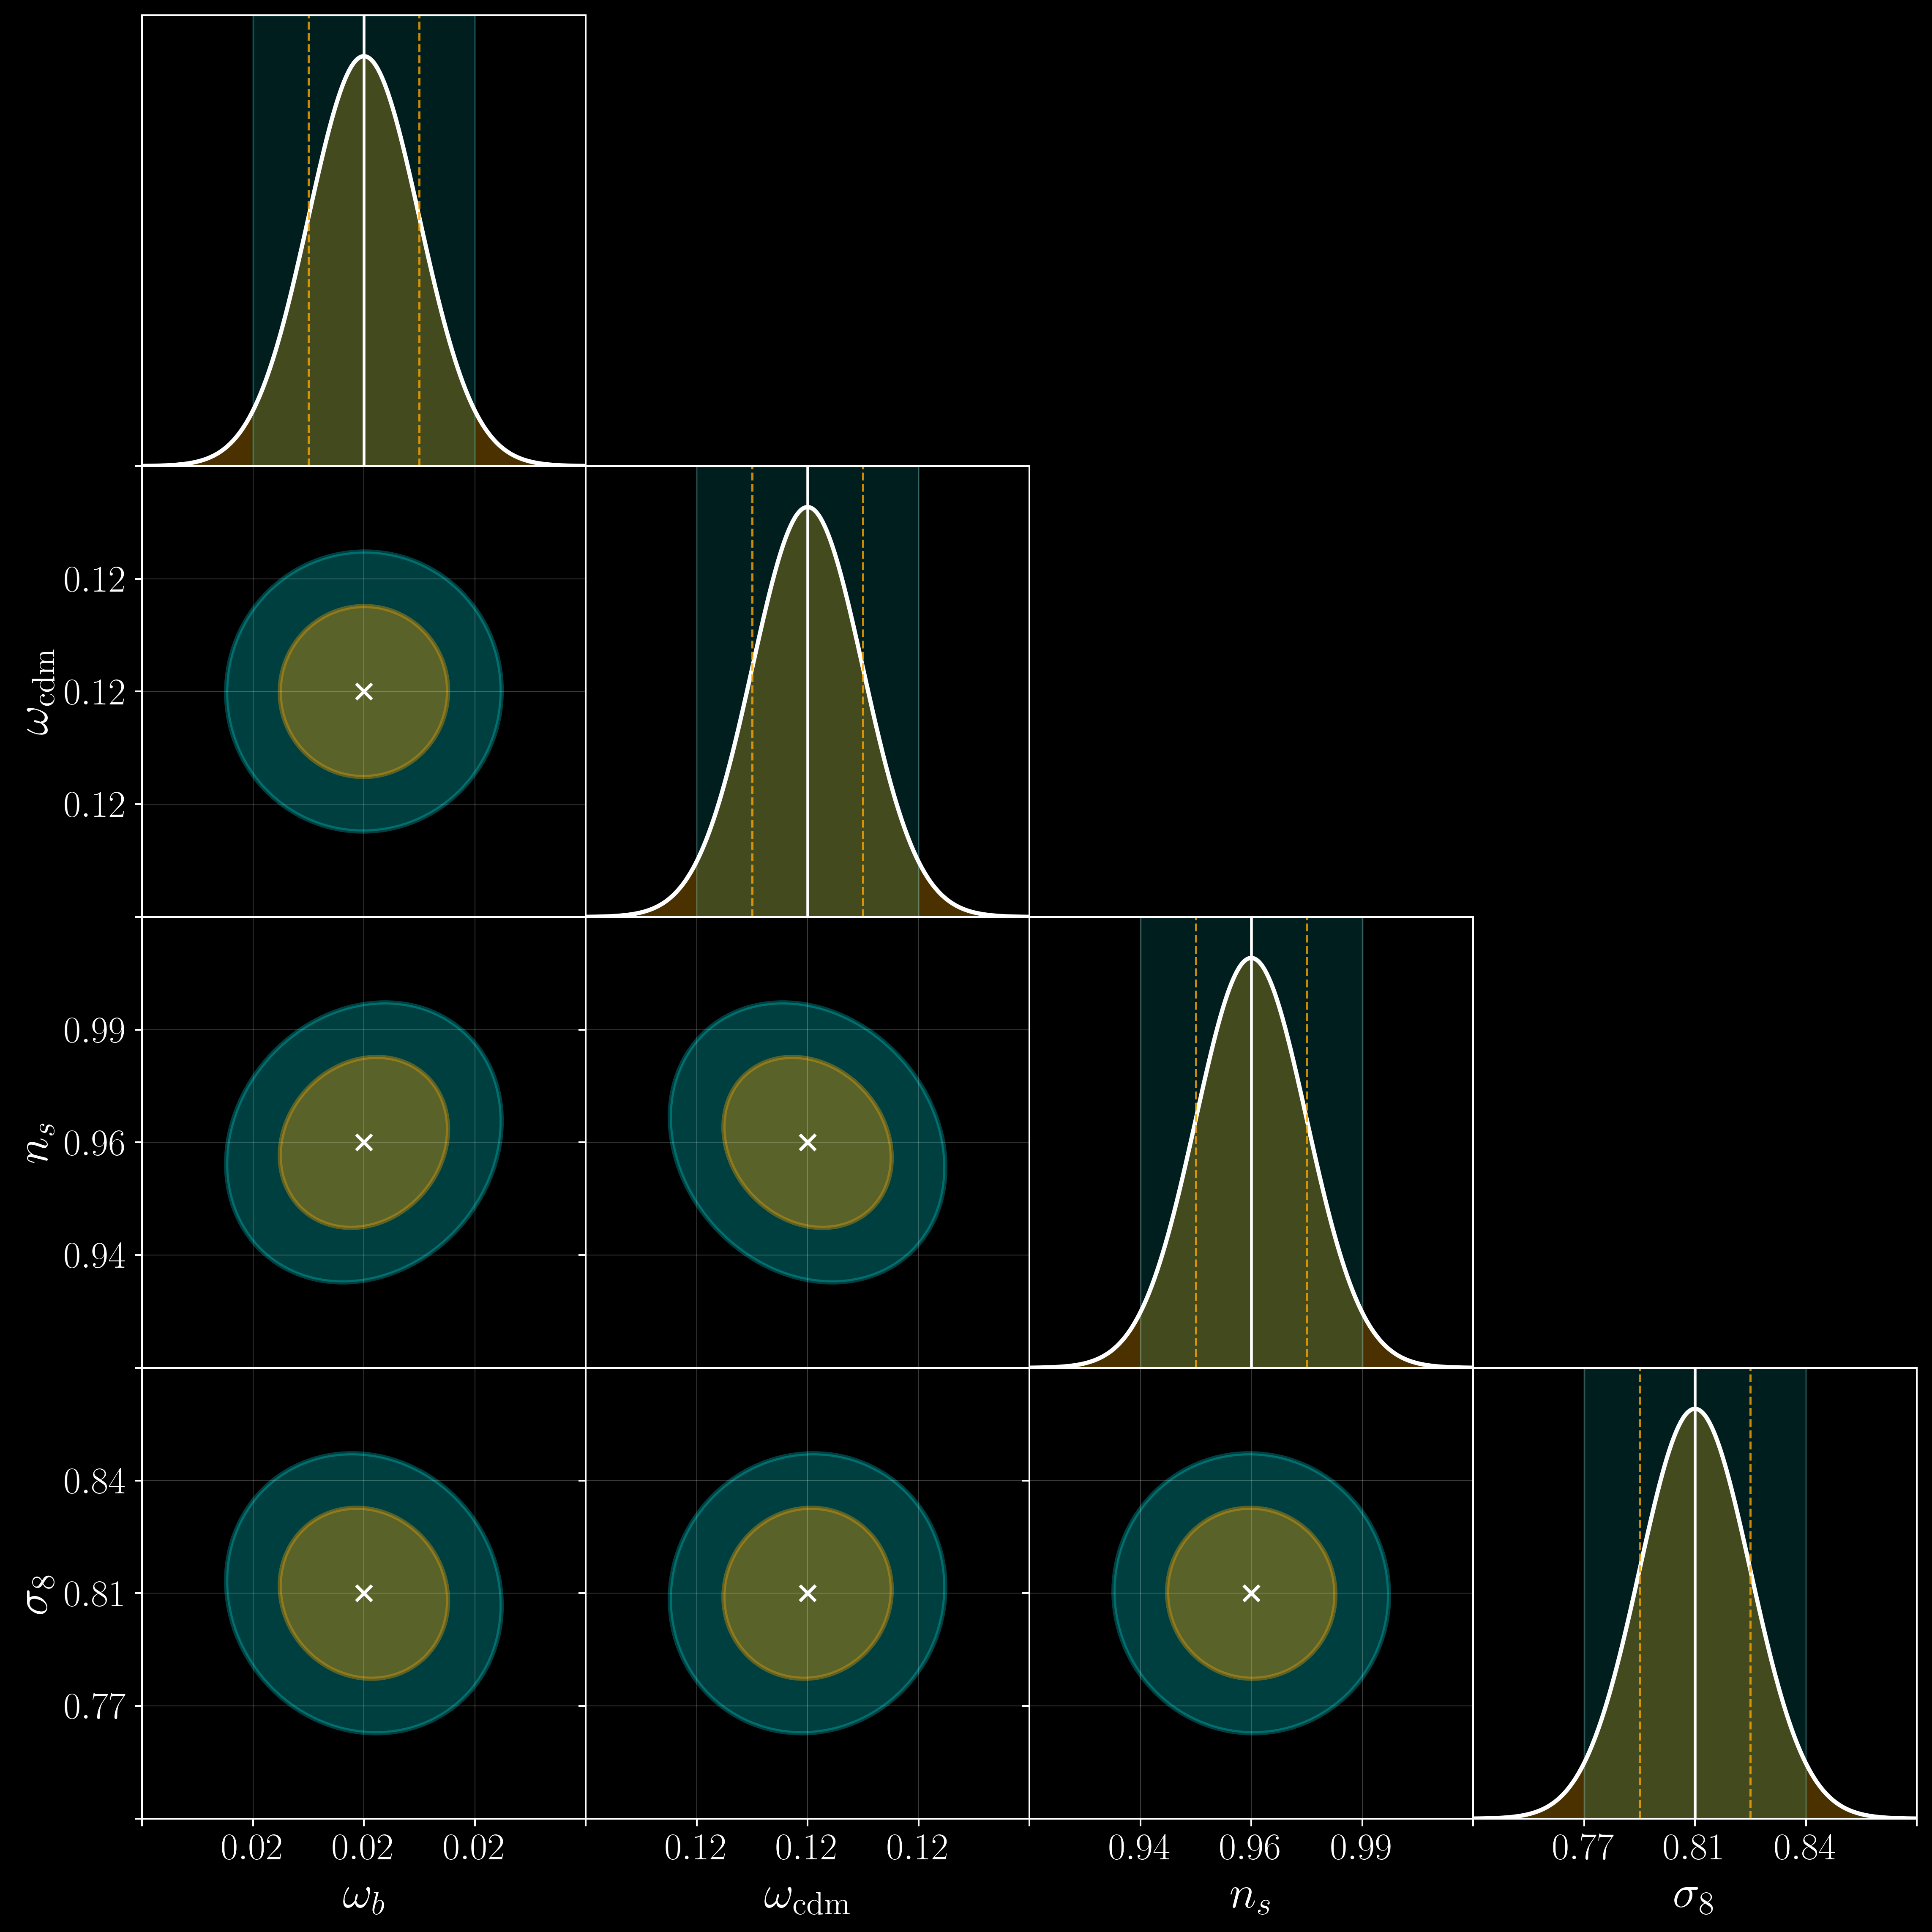

In [204]:
fig, axes = plt.subplots(npar, npar, figsize=(3.2*npar, 3.2*npar), sharex='col', sharey=False)

if npar == 1:
    axes = np.array([[axes]])

for row in range(npar):
    for col in range(npar):

        ax = axes[row, col]

        if col > row:
            ax.axis('off')
            continue

        if row == col:
            mu = theta_fid_cosmo[row]
            sig = np.sqrt(param_cov_cosmo[row, row])

            x = np.linspace(mu - 4 * sig, mu + 4 * sig, 500)

            y = np.exp(-0.5 * ((x - mu) / sig)**2)
            y /= y.max()

            ax.plot(x, y, color='white', lw=2)
            ax.fill_between(x, 0, y, color='orange', alpha=0.30)
            
            ax.axvline(mu, color='white', lw=1.3)
            
            ax.axvline(mu - sig, color='orange', lw=1, ls='--', alpha=0.8)
            ax.axvline(mu + sig, color='orange', lw=1, ls='--', alpha=0.8)

            ax.axvspan(mu-2*sig, mu+2*sig, color='cyan', alpha=0.12)

            ax.set_xlim(mu - 4 * sig, mu + 4 * sig)
            ax.set_ylim(0, 1.1)
            ax.set_yticks([])
            
            ax.grid(alpha=0.3, lw=0.3)

        else:
            i = row
            j = col

            cov2d = param_cov_cosmo[np.ix_([j, i], [j, i])]
            mean2d = theta_fid_cosmo[[j, i]]

            add_confidence_ellipse(ax, cov2d, mean2d,
                                   level=0.954,
                                   facecolor='cyan',
                                   edgecolor='cyan',
                                   alpha=0.25, lw=2)
            add_confidence_ellipse(ax, cov2d, mean2d,
                                   level=0.68,
                                   facecolor='orange',
                                   edgecolor='orange',
                                   alpha=0.35, lw=2)

            ax.scatter(mean2d[0], mean2d[1], marker='x',
                       s=55, c='white', lw=1.5)

            sig_x = np.sqrt(param_cov_cosmo[j, j])
            sig_y = np.sqrt(param_cov_cosmo[i, i])

            ax.set_xlim(mean2d[0] - 4 * sig_x,
                        mean2d[0] + 4 * sig_x)
            ax.set_ylim(mean2d[1] - 4 * sig_y,
                        mean2d[1] + 4 * sig_y)

            ax.grid(alpha=0.3, lw=0.3)

        if row == npar - 1:
            ax.set_xlabel(param_labels_cosmo[col], fontsize=22)
        if col == 0 and row > 0:
            ax.set_ylabel(param_labels_cosmo[row], fontsize=22)
        ax.tick_params(axis='both', labelsize=18)


for col in range(npar):
    mu = theta_fid_cosmo[col]
    sig = np.sqrt(param_cov_cosmo[col, col])

    for row in range(col, npar):
        ax = axes[row, col]
        if col > row:
            continue
        ax.set_xlim(mu - 4 * sig, mu + 4 * sig)


for row in range(1, npar):
    mu = theta_fid_cosmo[row]
    sig = np.sqrt(param_cov_cosmo[row, row])

    for col in range(row):
        ax = axes[row, col]
        ax.set_ylim(mu - 4 * sig, mu + 4 * sig)


for row in range(npar):
    for col in range(npar):

        ax = axes[row, col]

        if col > row:
            continue

        ax.xaxis.set_major_locator(LinearLocator(5))
        ax.xaxis.set_major_formatter(make_formatter(ax, axis='x',
                                                    ndec=tick_decimals_cosmo.get(col, 3)))

        if row == col:
            ax.set_yticks([])
        else:
            ax.yaxis.set_major_locator(LinearLocator(5))
            ax.yaxis.set_major_formatter(make_formatter(ax, axis='y',
                                                        ndec=tick_decimals_cosmo.get(row, 3)))

        if row < npar - 1:
            ax.tick_params(labelbottom=False)

        if col > 0:
            ax.tick_params(labelleft=False)

plt.tight_layout()
plt.subplots_adjust(wspace=0.0, hspace=0.0)
plt.savefig('conf_ellip_cosmo_marg_hod.png', dpi=360, bbox_inches='tight')
plt.show()

In [205]:
idx_hod = [4, 5, 6, 7, 8]

param_cov_hod = param_cov_full[np.ix_(idx_hod, idx_hod)]
theta_fid_hod_plot = theta_fid[idx_hod]
param_labels_hod = [param_labels[i] for i in idx_hod]

tick_decimals_hod = {0:2, 1:2, 2:2, 3:2, 4:2}
npar = len(idx_hod)

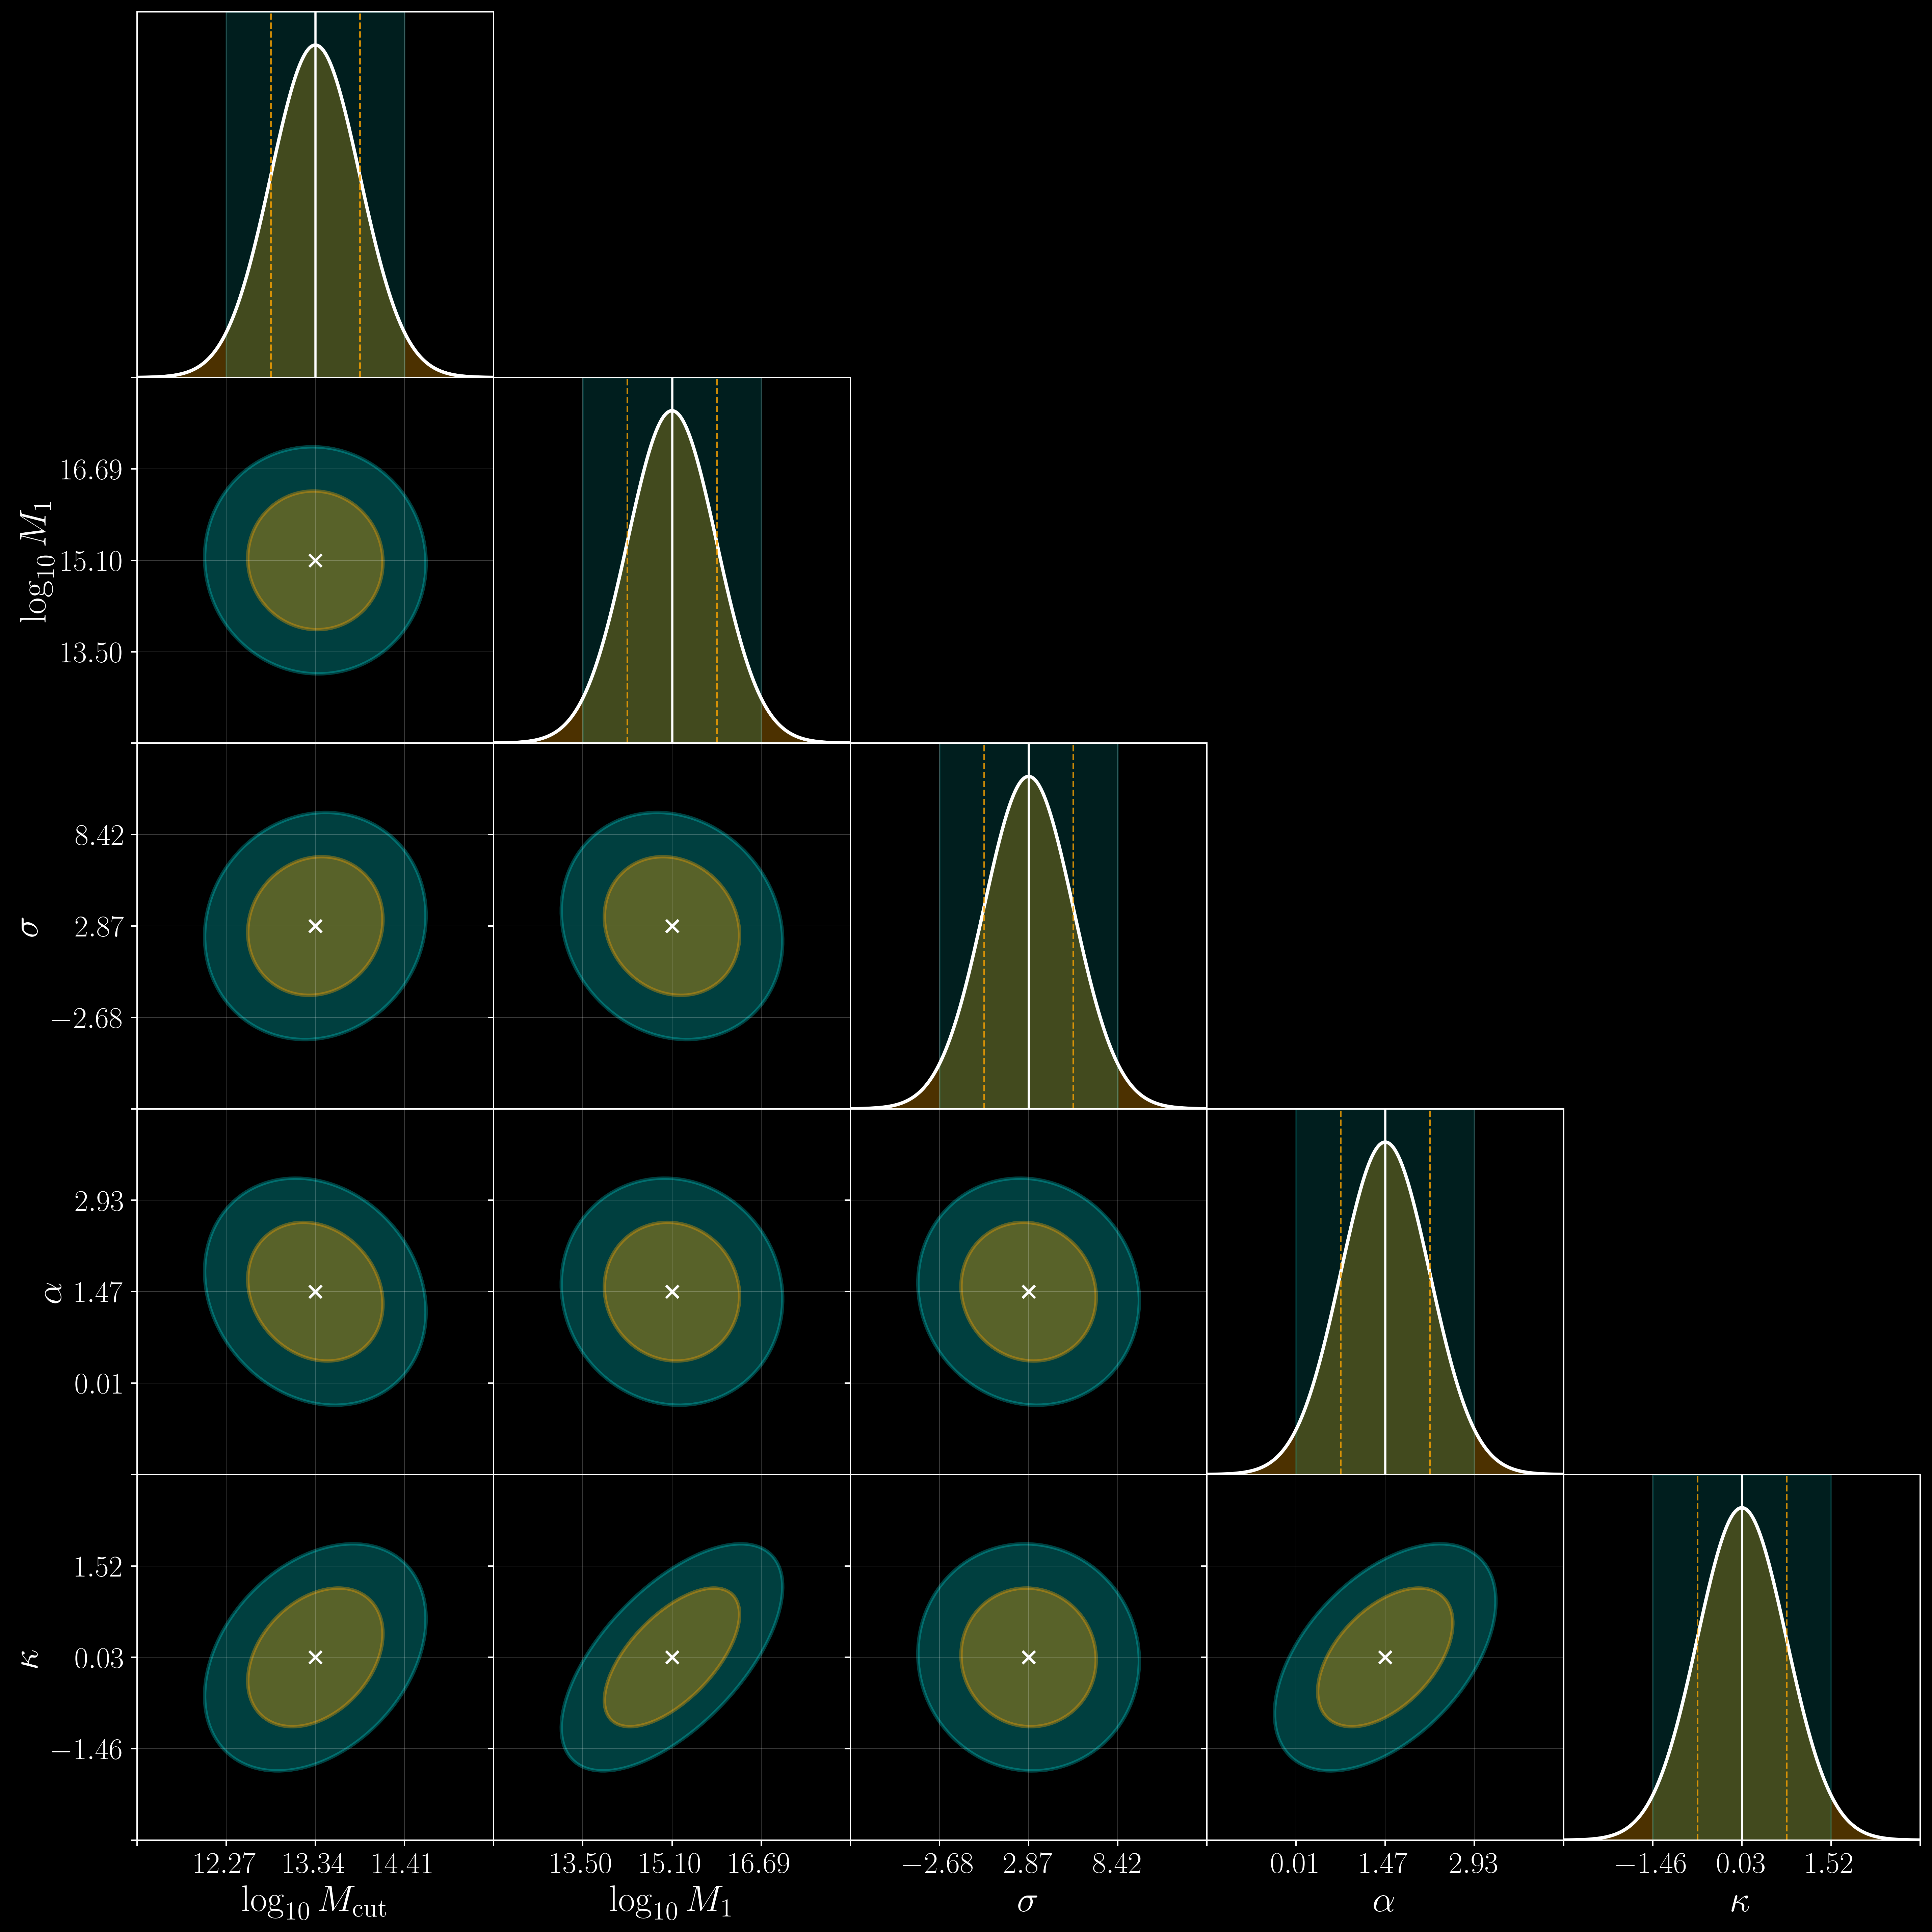

In [206]:
fig, axes = plt.subplots(npar, npar, figsize=(3.2*npar, 3.2*npar), sharex='col', sharey=False)

if npar == 1:
    axes = np.array([[axes]])

for row in range(npar):
    for col in range(npar):

        ax = axes[row, col]

        if col > row:
            ax.axis('off')
            continue

        if row == col:
            mu = theta_fid_hod_plot[row]
            sig = np.sqrt(param_cov_hod[row, row])

            x = np.linspace(mu - 4 * sig, mu + 4 * sig, 500)

            y = np.exp(-0.5 * ((x - mu) / sig)**2)
            y /= y.max()

            ax.plot(x, y, color='white', lw=2)
            ax.fill_between(x, 0, y, color='orange', alpha=0.30)
            
            ax.axvline(mu, color='white', lw=1.3)
            
            ax.axvline(mu - sig, color='orange', lw=1, ls='--', alpha=0.8)
            ax.axvline(mu + sig, color='orange', lw=1, ls='--', alpha=0.8)

            ax.axvspan(mu-2*sig, mu+2*sig, color='cyan', alpha=0.12)

            ax.set_xlim(mu - 4 * sig, mu + 4 * sig)
            ax.set_ylim(0, 1.1)
            ax.set_yticks([])
            
            ax.grid(alpha=0.3, lw=0.3)

        else:
            i = row
            j = col

            cov2d = param_cov_hod[np.ix_([j, i], [j, i])]
            mean2d = theta_fid_hod_plot[[j, i]]

            add_confidence_ellipse(ax, cov2d, mean2d,
                                   level=0.954,
                                   facecolor='cyan',
                                   edgecolor='cyan',
                                   alpha=0.25, lw=2)
            add_confidence_ellipse(ax, cov2d, mean2d,
                                   level=0.68,
                                   facecolor='orange',
                                   edgecolor='orange',
                                   alpha=0.35, lw=2)

            ax.scatter(mean2d[0], mean2d[1], marker='x',
                       s=55, c='white', lw=1.5)

            sig_x = np.sqrt(param_cov_hod[j, j])
            sig_y = np.sqrt(param_cov_hod[i, i])

            ax.set_xlim(mean2d[0] - 4 * sig_x,
                        mean2d[0] + 4 * sig_x)
            ax.set_ylim(mean2d[1] - 4 * sig_y,
                        mean2d[1] + 4 * sig_y)

            ax.grid(alpha=0.3, lw=0.3)

        if row == npar - 1:
            ax.set_xlabel(param_labels_hod[col], fontsize=22)
        if col == 0 and row > 0:
            ax.set_ylabel(param_labels_hod[row], fontsize=22)
        ax.tick_params(axis='both', labelsize=18)


for col in range(npar):
    mu = theta_fid_hod_plot[col]
    sig = np.sqrt(param_cov_hod[col, col])

    for row in range(col, npar):
        ax = axes[row, col]
        if col > row:
            continue
        ax.set_xlim(mu - 4 * sig, mu + 4 * sig)


for row in range(1, npar):
    mu = theta_fid_hod_plot[row]
    sig = np.sqrt(param_cov_hod[row, row])

    for col in range(row):
        ax = axes[row, col]
        ax.set_ylim(mu - 4 * sig, mu + 4 * sig)


for row in range(npar):
    for col in range(npar):

        ax = axes[row, col]

        if col > row:
            continue

        ax.xaxis.set_major_locator(LinearLocator(5))
        ax.xaxis.set_major_formatter(make_formatter(ax, axis='x',
                                                    ndec=tick_decimals_hod.get(col, 3)))

        if row == col:
            ax.set_yticks([])
        else:
            ax.yaxis.set_major_locator(LinearLocator(5))
            ax.yaxis.set_major_formatter(make_formatter(ax, axis='y',
                                                        ndec=tick_decimals_hod.get(row, 3)))

        if row < npar - 1:
            ax.tick_params(labelbottom=False)

        if col > 0:
            ax.tick_params(labelleft=False)

plt.tight_layout()
plt.subplots_adjust(wspace=0.0, hspace=0.0)
plt.savefig('conf_ellip_only_hod.png', dpi=360, bbox_inches='tight')
plt.show()